        # Intelligent Resume Automation with a Smart OCR Pipeline

        This notebook follows the same flow as the receipt OCR project, but applies it to the `snehaanbhawal/resume-dataset` Kaggle dataset. We will:

        1. Download the resume dataset
        2. Inspect the PDF and CSV structure
        3. Convert PDF resumes into images
        4. Preprocess the pages with OpenCV
        5. Extract text with Tesseract OCR
        6. Generate structured JSON from the resume content
        


        # Our Approach

        Resume documents are usually multi-page PDFs, so we need one additional step compared to the receipt notebook: **PDF to image conversion**. After that, the flow remains very similar:

        `PDF -> page images -> grayscale -> noise reduction -> thresholding -> deskew -> OCR -> structured extraction`
        


        # Resume Dataset

        Dataset: `https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset`

        The dataset contains:

        - Resume PDFs stored inside category folders
        - A CSV file with:
          - `ID`
          - `Resume_str`
          - `Resume_html`
          - `Category`

        We will use the PDFs for OCR and optionally use the CSV text as supporting context.
        


In [1]:
        !pip install kagglehub pymupdf opencv-python matplotlib numpy pandas pytesseract pillow tqdm google-genai



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 64.7 MB/s eta 0:00:00


## Getting the data


In [2]:
        import kagglehub

        path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
        print("Path to dataset files:", path)



Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [3]:
        import os
        from pathlib import Path

        dataset_path = Path(path)
        all_files = sorted(dataset_path.rglob("*"))
        print("Total files/folders discovered:", len(all_files))

        for item in all_files[:30]:
            print(item)



Total files/folders discovered: 2512
/kaggle/input/resume-dataset/Resume
/kaggle/input/resume-dataset/Resume/Resume.csv
/kaggle/input/resume-dataset/data
/kaggle/input/resume-dataset/data/data
/kaggle/input/resume-dataset/data/data/ACCOUNTANT
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/10554236.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/10674770.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/11163645.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/11759079.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/12065211.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/12202337.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/12338274.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/12442909.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/12780508.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/12802330.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/13072019.pdf
/kaggle/input/resume-dataset/data/data/ACCOUNTANT/13130984.pdf
/

## Understanding the data


In [4]:
        import pandas as pd

        csv_files = list(dataset_path.rglob("*.csv"))
        pdf_files = list(dataset_path.rglob("*.pdf"))

        print("CSV files found:", [str(f) for f in csv_files])
        print("Total PDF files found:", len(pdf_files))

        resume_df = pd.read_csv(csv_files[0])
        resume_df.head()



CSV files found: ['/kaggle/input/resume-dataset/Resume/Resume.csv']
Total PDF files found: 2484


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [5]:
        resume_df.columns = [col.strip().lower() for col in resume_df.columns]
        resume_df.head(3)



,id,resume_str,resume_html,category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [6]:
        resume_df["category"].value_counts().head(10)



,count
category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


In [7]:
        sample_pdf = pdf_files[0]
        print("Sample PDF:", sample_pdf)

        sample_id = Path(sample_pdf).stem
        csv_match = resume_df[resume_df["id"].astype(str) == sample_id]
        csv_match[["id", "category"]].head(1)



Sample PDF: /kaggle/input/resume-dataset/data/data/DESIGNER/22506245.pdf


,id,category
189,22506245,DESIGNER


        ## Converting PDF to images

        Since resumes are PDFs, we render each page into an image before applying the same OCR-oriented preprocessing steps from the receipt notebook.
        


In [8]:
        import fitz  # PyMuPDF
        import cv2
        import numpy as np
        import matplotlib.pyplot as plt

        def render_pdf_to_images(pdf_path, zoom=2):
            doc = fitz.open(pdf_path)
            images = []

            for page in doc:
                matrix = fitz.Matrix(zoom, zoom)
                pix = page.get_pixmap(matrix=matrix, alpha=False)
                image = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
                image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
                images.append(image)

            doc.close()
            return images

        def display_image(image, title="Image", cmap=None):
            plt.figure(figsize=(8, 10))
            if len(image.shape) == 2:
                plt.imshow(image, cmap=cmap or "gray")
            else:
                plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.title(title)
            plt.axis("off")
            plt.show()



Number of pages in sample resume: 1


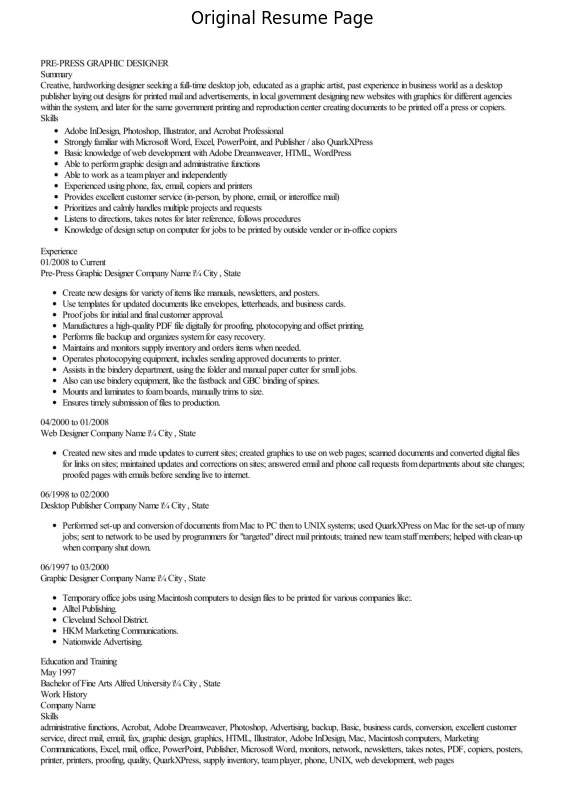

In [9]:
        sample_pages = render_pdf_to_images(sample_pdf)
        print("Number of pages in sample resume:", len(sample_pages))
        display_image(sample_pages[0], "Original Resume Page")



        ## Image Preprocessing: OpenCV

        The same preprocessing ideas still help here:

        - Grayscale simplifies the page
        - Gaussian blur reduces noise
        - Adaptive thresholding improves text contrast
        - Deskewing helps OCR read slightly tilted pages
        


In [10]:
        def convert_to_grayscale(image):
            return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        def reduce_noise(gray_image):
            return cv2.GaussianBlur(gray_image, (5, 5), 0)

        def binarize_image(blur_reduced_image):
            return cv2.adaptiveThreshold(
                blur_reduced_image,
                255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY,
                31,
                15,
            )

        def deskew_image(image):
            coords = cv2.findNonZero(255 - image)
            if coords is None:
                return image

            rect = cv2.minAreaRect(coords)
            angle = rect[-1]

            if angle < -45:
                angle = -(90 + angle)
            else:
                angle = -angle

            (h, w) = image.shape[:2]
            center = (w // 2, h // 2)
            rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

            return cv2.warpAffine(
                image,
                rotation_matrix,
                (w, h),
                flags=cv2.INTER_CUBIC,
                borderMode=cv2.BORDER_REPLICATE,
            )

        def process_one_image(image):
            image = convert_to_grayscale(image)
            image = reduce_noise(image)
            image = binarize_image(image)
            image = deskew_image(image)
            return image



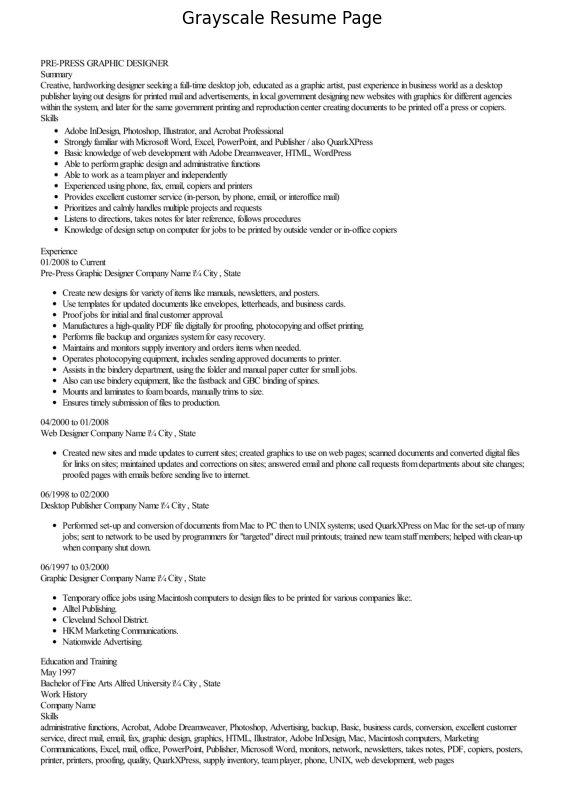

In [11]:
        grayscale_image = convert_to_grayscale(sample_pages[0])
        display_image(grayscale_image, "Grayscale Resume Page")



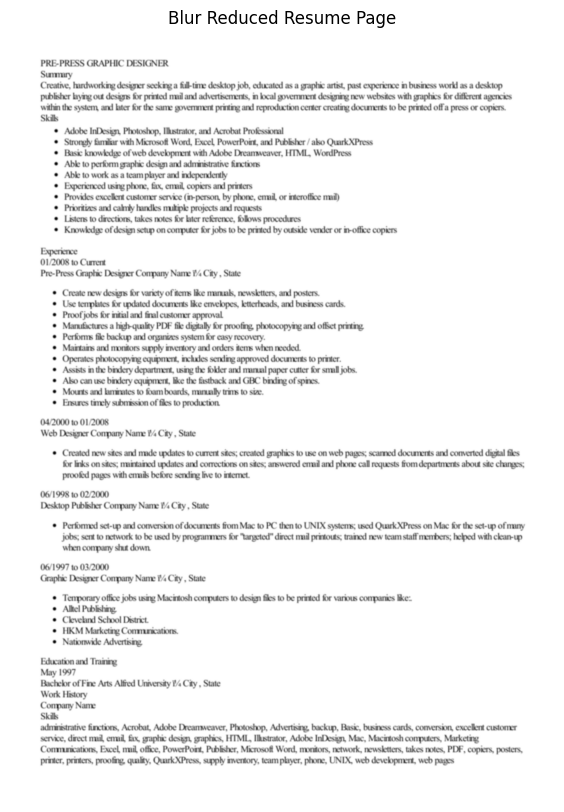

In [12]:
        blur_reduced_image = reduce_noise(grayscale_image)
        display_image(blur_reduced_image, "Blur Reduced Resume Page")



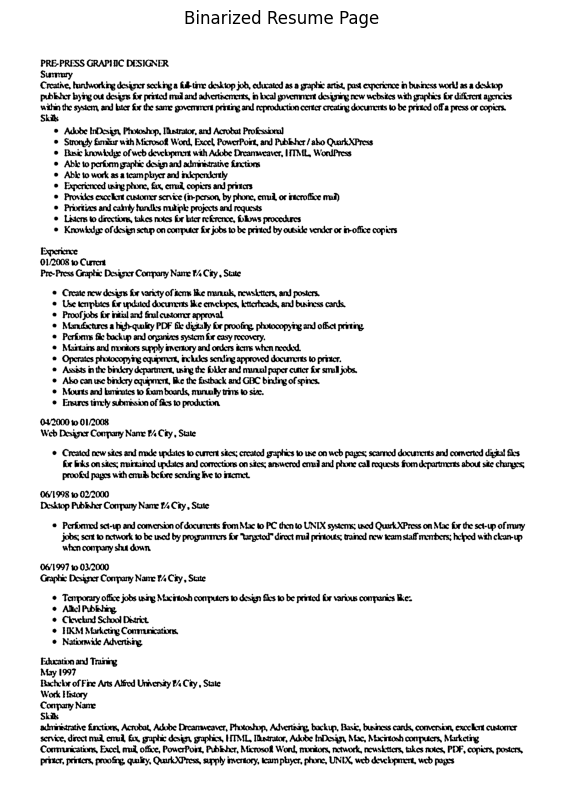

In [13]:
        binarized_image = binarize_image(blur_reduced_image)
        display_image(binarized_image, "Binarized Resume Page")



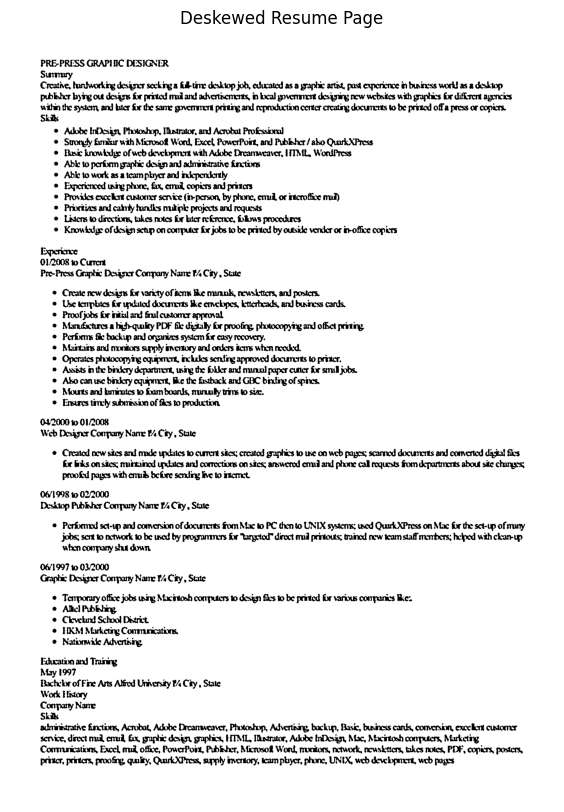

In [14]:
        deskewed_image = deskew_image(binarized_image)
        display_image(deskewed_image, "Deskewed Resume Page")



## Batch preprocessing


In [15]:
        import time
        from tqdm.auto import tqdm

        processed_root = Path("/content/resume_processed_pages")
        processed_root.mkdir(parents=True, exist_ok=True)

        selected_pdfs = pdf_files[:10]
        start_time = time.time()

        for pdf_path in tqdm(selected_pdfs):
            pdf_id = Path(pdf_path).stem
            page_output_dir = processed_root / pdf_id
            page_output_dir.mkdir(parents=True, exist_ok=True)

            pages = render_pdf_to_images(pdf_path)

            for page_num, page_image in enumerate(pages, start=1):
                processed_image = process_one_image(page_image)
                output_path = page_output_dir / f"page_{page_num}.png"
                cv2.imwrite(str(output_path), processed_image)

        print("Processing pages is completed.")
        print(f"Total time taken: {time.time() - start_time:.2f} seconds")



  0%|          | 0/10 [00:00<?, ?it/s]

Processing pages is completed.
Total time taken: 2.08 seconds


## Text Extraction: Tesseract


In [16]:
        from PIL import Image
        import pytesseract

        sample_processed_page = next(processed_root.rglob("*.png"))
        print(sample_processed_page)
        print(pytesseract.image_to_string(Image.open(sample_processed_page))[:2000])



/content/resume_processed_pages/11807040/page_2.png
Trained new staff on quality cocarol procedures,

Followed infection control procedures.

Assbted paticnts with daily finctions,

Monitored fad intake and ouput kvek,

Extensie experince working in homes with dxabled chikiren and adults,

Measured urine and delivered specimens to bb.

Provided all daily hing tasks to enhance quality of ie for cklerly patients,

Performed prepnuncy tests and sent specimens for tiboratory testing,

Assbted residents with bathing, dressing, Reding, lifing and transferrng,
Experience with various medical conditions inching Parkinson's, Dementia, Dubetes, Cancer, Aldciner’s and Paget's disease.
Assisted doctors with sungerics and non- imasive procedures,

Authorized drug reflls and provided detailed prescription inforration to phantacics.
Colkxcted blood, tissue and other Lboratory specimens and prepared them for lub testing,
Developed and produced al office flyer notifications for important policy changrs

In [18]:
import time
from tqdm.auto import tqdm

ocr_root = Path("/content/resume_tesseract_output")
ocr_root.mkdir(parents=True, exist_ok=True)

start_time = time.time()

for pdf_dir in sorted(processed_root.iterdir()):
    if not pdf_dir.is_dir():
        continue

    page_texts = []

    for page_image_path in sorted(pdf_dir.glob("*.png")):
        text = pytesseract.image_to_string(Image.open(page_image_path))
        page_texts.append(
            f"\n\n===== {page_image_path.stem.upper()} =====\n{text}"
        )

    combined_text = "".join(page_texts).strip()
    output_path = ocr_root / f"{pdf_dir.name}.txt"

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(combined_text)

print("Text extraction completed.")
print(f"Total time taken: {time.time() - start_time:.2f} seconds")

Text extraction completed.
Total time taken: 214.45 seconds


## Information Extraction


In [19]:
        extraction_prompt = '''
        Extract structured resume information from the given resume image pages and OCR text.

        Information to extract:
        - full_name
        - email
        - phone
        - location
        - professional_summary
        - skills
        - education
        - experience
        - certifications
        - category

        Rules:
        - Return valid JSON only
        - If a field is missing, use null
        - `skills`, `education`, `experience`, and `certifications` should be arrays
        - Preserve the candidate's meaning, but fix obvious OCR mistakes when needed

        JSON format:
        {
          "full_name": "CANDIDATE_NAME",
          "email": "EMAIL",
          "phone": "PHONE",
          "location": "LOCATION",
          "professional_summary": "SHORT_SUMMARY",
          "skills": ["SKILL_1", "SKILL_2"],
          "education": ["EDUCATION_1", "EDUCATION_2"],
          "experience": ["EXPERIENCE_1", "EXPERIENCE_2"],
          "certifications": ["CERT_1", "CERT_2"],
          "category": "RESUME_CATEGORY"
        }
        '''



In [23]:
from google import genai
import json

from google.colab import userdata
genai_client = genai.Client(api_key=userdata.get("Default_Gemini_API_Key"))

In [24]:
json_root = Path("/content/resume_json_output")
json_root.mkdir(parents=True, exist_ok=True)



In [25]:
sample_resume_id = Path(sample_pdf).stem
sample_ocr_path = ocr_root / f"{sample_resume_id}.txt"
sample_csv_text = csv_match["resume_str"].iloc[0] if not csv_match.empty else ""

print("Resume ID:", sample_resume_id)
print("OCR text preview:")
print(sample_ocr_path.read_text(encoding="utf-8")[:1500])



Resume ID: 22506245
OCR text preview:
===== PAGE_1 =====
PRE-PRESS GRAPHIC DESIGNER
Sunmury
(Creative, hardworking designer secking a fulltime desktop job, educated as a graphic artht, past experience in business world as a desktop
Publisher ying out designs for printed mail and advertisements, in local government designing new websites with graphics for dificrent agencies.
‘within the system, and biter for the same government printing and reproduction center creating documents to be printed off a press or copicrs.
Skis
* Adobe InDesign, Photoshop, Itustrator, and Acrobat Proféssional
Swongy famiur with Microsoft Word, Excel, PowerPoint, and Publisher / alo QuarkXPress
Basic knowbdge of web development with Adobe Dreammeaver, IITML, WordPress
Able: to perform graphic design and admnnstrathe functions
Abk to work as a team phryer and independently
Experienced using phone, fax, email, copiers and printers
Provides excellent customer service (in-person, by phone, emuil, or ntcrofiive mail

In [27]:
ocr_text = sample_ocr_path.read_text(encoding="utf-8")

print(f"OCR TEXT: {ocr_text}")
print(f"CSV RESUME TEXT: {sample_csv_text}")

OCR TEXT: ===== PAGE_1 =====
PRE-PRESS GRAPHIC DESIGNER
Sunmury
(Creative, hardworking designer secking a fulltime desktop job, educated as a graphic artht, past experience in business world as a desktop
Publisher ying out designs for printed mail and advertisements, in local government designing new websites with graphics for dificrent agencies.
‘within the system, and biter for the same government printing and reproduction center creating documents to be printed off a press or copicrs.
Skis
* Adobe InDesign, Photoshop, Itustrator, and Acrobat Proféssional
Swongy famiur with Microsoft Word, Excel, PowerPoint, and Publisher / alo QuarkXPress
Basic knowbdge of web development with Adobe Dreammeaver, IITML, WordPress
Able: to perform graphic design and admnnstrathe functions
Abk to work as a team phryer and independently
Experienced using phone, fax, email, copiers and printers
Provides excellent customer service (in-person, by phone, emuil, or ntcrofiive mail)
Prioritives and calmly han